---
title: "PheWAS example"
author: Gibran Hemani
date: "2026-05-22"
categories: []
---

In [7]:
library(TwoSampleMR)
library(dplyr)
library(ggplot2)
library(ieugwasr)

TwoSampleMR version 0.7.6 


  [>] New authentication requirements: https://mrcieu.github.io/ieugwasr/articles/guide.html#authentication.

  [>] Major upgrades to our servers completed to improve service and stability.

  [>] We need your help to shape our emerging roadmap!

      Please take 2 minutes to give us feedback -

      https://forms.office.com/e/eSr7EFAfCG


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


OpenGWAS updates:

  Date: 2024-05-17

  [>] OpenGWAS is growing!

  [>] Please take 2 minutes to give us feedback -

  [>] It will help directly shape our emerging roadmap

  [>] https://forms.office.com/e/eSr7EFAfCG


Attaching package: ‘ieugwasr’


The following object is masked from ‘package:TwoSampleMR’:

    ld_matrix




Let's use the 2015 GWAS for Coronary Artery Disease as an example. 

- Identify the GWAS hits for CAD
- Choose one as an example
- Objective: are there any traits that appear to mediate the path from SNP -> CHD
- For candidate traits, use MR to test if it's associated with CHD

In [8]:
chd <- TwoSampleMR::extract_instruments("ieu-a-7")
str(chd)

'data.frame':	41 obs. of  15 variables:
 $ id.exposure           : chr  "ieu-a-7" "ieu-a-7" "ieu-a-7" "ieu-a-7" ...
 $ chr.exposure          : chr  "9" "6" "6" "1" ...
 $ pos.exposure          : int  22098619 12903957 161005610 109817192 203893999 79124475 160687412 35593827 11188247 44480811 ...
 $ SNP                   : chr  "rs2891168" "rs9349379" "rs55730499" "rs7528419" ...
 $ effect_allele.exposure: chr  "G" "G" "T" "G" ...
 $ other_allele.exposure : chr  "A" "A" "C" "A" ...
 $ eaf.exposure          : num  0.4887 0.4316 0.0562 0.2142 0.107 ...
 $ beta.exposure         : num  0.193 0.132 0.317 -0.115 0.138 ...
 $ se.exposure           : num  0.00919 0.00965 0.02424 0.01148 0.01583 ...
 $ pval.exposure         : num  2.29e-98 1.81e-42 5.39e-39 1.97e-23 3.12e-18 ...
 $ samplesize.exposure   : num  184305 184305 184305 184305 184305 ...
 $ exposure              : chr  "Coronary heart disease || id:ieu-a-7" "Coronary heart disease || id:ieu-a-7" "Coronary heart disease || id:ieu-a-7"

For illustration let's look at just the first SNP in the list. What traits might mediate the path from this SNP to the outcome?

In [9]:
snp <- chd$SNP[1]
snp

[1] "rs2891168"

In [10]:
phewas_result <- ieugwasr::phewas(snp, batch="ukb-b")
str(phewas_result)

tibble [84 × 12] (S3: tbl_df/tbl/data.frame)
 $ id      : chr [1:84] "ukb-b-1668" "ukb-b-18408" "ukb-b-8650" "ukb-b-8468" ...
 $ trait   : chr [1:84] "Diagnoses - main ICD10: I25.1 Atherosclerotic heart disease" "Illnesses of father: Heart disease" "Non-cancer illness code, self-reported: angina" "Vascular/heart problems diagnosed by doctor: Angina" ...
 $ chr     : chr [1:84] "9" "9" "9" "9" ...
 $ position: int [1:84] 22098619 22098619 22098619 22098619 22098619 22098619 22098619 22098619 22098619 22098619 ...
 $ rsid    : chr [1:84] "rs2891168" "rs2891168" "rs2891168" "rs2891168" ...
 $ ea      : chr [1:84] "G" "G" "G" "G" ...
 $ nea     : chr [1:84] "A" "A" "A" "A" ...
 $ eaf     : num [1:84] 0.49 0.49 0.49 0.49 0.49 ...
 $ beta    : num [1:84] 0.00586 0.01652 0.00503 0.00498 0.00238 ...
 $ se      : num [1:84] 0.00033 0.001037 0.000364 0.000365 0.00018 ...
 $ p       : num [1:84] 2.2e-70 4.1e-57 2.0e-43 2.3e-42 5.0e-40 ...
 $ n       : num [1:84] 463010 407557 462933 461880 462933

In [11]:
for(i in 1:nrow(phewas_result)) {
  message(i, ": ", phewas_result$p[i], " - ", phewas_result$trait[i])
}

1: 2.19989e-70 - Diagnoses - main ICD10: I25.1 Atherosclerotic heart disease

2: 4.10015e-57 - Illnesses of father: Heart disease

3: 1.99986e-43 - Non-cancer illness code, self-reported: angina

4: 2.29985e-42 - Vascular/heart problems diagnosed by doctor: Angina

5: 5.00035e-40 - Operation code: coronary artery bypass grafts (cabg)

6: 4.79954e-39 - Non-cancer illness code, self-reported: heart attack/myocardial infarction

7: 5.70033e-38 - Vascular/heart problems diagnosed by doctor: Heart attack

8: 6.70039e-33 - Diagnoses - secondary ICD10: Z95.1 Presence of aortocoronary bypass graft

9: 2.19989e-31 - Diagnoses - secondary ICD10: I20.9 Angina pectoris, unspecified

10: 7.50067e-30 - Operative procedures - main OPCS: K45.3 Anastomosis of mammary artery to left anterior descending coronary artery

11: 1.10002e-29 - Treatment speciality of consultant (recoded): Cardiology

12: 1.99986e-29 - Operation code: coronary angioplasty (ptca) +/- stent

13: 7.00003e-29 - Diagnoses - secondar

In [12]:
follow_up <- phewas_result$id[c(46, 67)]
follow_up_instruments <- extract_instruments(outcomes = follow_up)
str(follow_up_instruments)

Warning message in FUN(X[[i]], ...):
“Duplicated SNPs present in exposure data for phenotype 'Diastolic blood pressure, automated reading || id:ukb-b-7992. Just keeping the first instance:
rs28752924”


'data.frame':	281 obs. of  15 variables:
 $ id.exposure           : chr  "ukb-b-17324" "ukb-b-17324" "ukb-b-17324" "ukb-b-17324" ...
 $ chr.exposure          : chr  "1" "9" "4" "17" ...
 $ pos.exposure          : int  165739598 22036367 7888830 10031183 107695848 129375338 61091401 637465 108276873 14837332 ...
 $ SNP                   : chr  "rs2814471" "rs1556515" "rs55937650" "rs9913911" ...
 $ effect_allele.exposure: chr  "T" "T" "T" "G" ...
 $ other_allele.exposure : chr  "C" "C" "C" "A" ...
 $ eaf.exposure          : num  0.876 0.57 0.594 0.374 0.556 ...
 $ beta.exposure         : num  -0.01554 0.00698 -0.00663 -0.00644 -0.00614 ...
 $ se.exposure           : num  0.001123 0.000745 0.000752 0.000764 0.000748 ...
 $ pval.exposure         : num  1.5e-43 7.2e-21 1.2e-18 3.6e-17 2.3e-16 ...
 $ samplesize.exposure   : num  150642 150642 150642 150642 150642 ...
 $ exposure              : chr  "Eye problems/disorders: Glaucoma || id:ukb-b-17324" "Eye problems/disorders: Glaucoma || id:

In [13]:
i <- which(chd$SNP == snp)

follow_up_instruments_target_region <- follow_up_instruments %>%
    filter(chr.exposure == chd$chr.exposure[i] & abs(pos.exposure - chd$pos.exposure[i]) < 1e6) %>%
    mutate(
        id.exposure = paste("target region - ", id.exposure),
        exposure = paste("target region - ", exposure)
    )
str(follow_up_instruments_target_region)


'data.frame':	2 obs. of  15 variables:
 $ id.exposure           : chr  "target region -  ukb-b-17324" "target region -  ukb-b-7992"
 $ chr.exposure          : chr  "9" "9"
 $ pos.exposure          : int  22036367 22003223
 $ SNP                   : chr  "rs1556515" "rs3217992"
 $ effect_allele.exposure: chr  "T" "T"
 $ other_allele.exposure : chr  "C" "C"
 $ eaf.exposure          : num  0.57 0.369
 $ beta.exposure         : num  0.00698 -0.01334
 $ se.exposure           : num  0.000745 0.002146
 $ pval.exposure         : num  7.2e-21 5.2e-10
 $ samplesize.exposure   : num  150642 436424
 $ exposure              : chr  "target region -  Eye problems/disorders: Glaucoma || id:ukb-b-17324" "target region -  Diastolic blood pressure, automated reading || id:ukb-b-7992"
 $ mr_keep.exposure      : logi  TRUE TRUE
 $ pval_origin.exposure  : chr  "reported" "reported"
 $ data_source.exposure  : chr  "igd" "igd"


In [14]:
follow_up_instruments <- subset(follow_up_instruments, !SNP %in% follow_up_instruments_target_region$SNP) %>% 
    bind_rows(follow_up_instruments_target_region)
table(follow_up_instruments$exposure)


                 Diastolic blood pressure, automated reading || id:ukb-b-7992 
                                                                          262 
                           Eye problems/disorders: Glaucoma || id:ukb-b-17324 
                                                                           17 
target region -  Diastolic blood pressure, automated reading || id:ukb-b-7992 
                                                                            1 
          target region -  Eye problems/disorders: Glaucoma || id:ukb-b-17324 
                                                                            1 

In [15]:
out <- extract_outcome_data(snps = follow_up_instruments$SNP, outcomes = "ieu-a-7")
dat <- harmonise_data(follow_up_instruments, out, action = 3)
mr_result <- mr(dat, method_list=c("mr_ivw", "mr_wald_ratio"))

Extracting data for 281 SNP(s) from 1 GWAS(s)

Querying id chunk 1 of 1

Querying variant chunk 1 of 5



In [23]:
mr_result

id.exposure,id.outcome,outcome,exposure,method,nsnp,b,se,pval
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ukb-b-7992,ieu-a-7,Coronary heart disease || id:ieu-a-7,"Diastolic blood pressure, automated reading || id:ukb-b-7992",Inverse variance weighted,219,0.5968246,0.07740218,1.251344e-14
ukb-b-17324,ieu-a-7,Coronary heart disease || id:ieu-a-7,Eye problems/disorders: Glaucoma || id:ukb-b-17324,Inverse variance weighted,15,1.0113659,0.48597125,3.742266e-02
target region - ukb-b-17324,ieu-a-7,Coronary heart disease || id:ieu-a-7,target region - Eye problems/disorders: Glaucoma || id:ukb-b-17324,Wald ratio,1,15.6902580,2.37510702,3.945052e-11
target region - ukb-b-7992,ieu-a-7,Coronary heart disease || id:ieu-a-7,"target region - Diastolic blood pressure, automated reading || id:ukb-b-7992",Wald ratio,1,-9.6217063,0.70237399,1.031644e-42


`height` was translated to `width`.


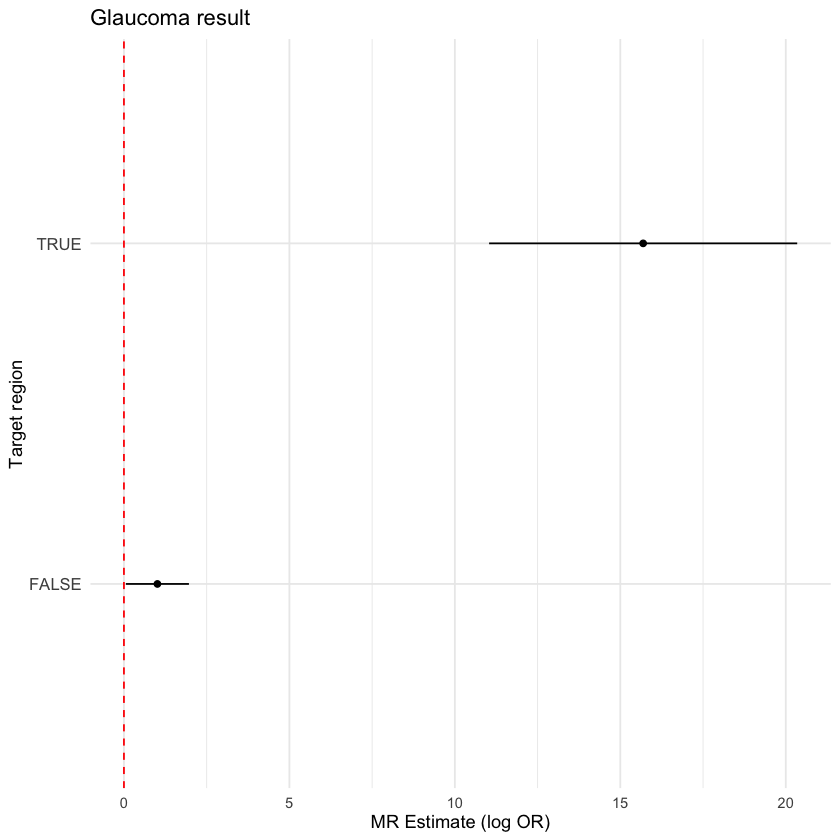

In [26]:
ggplot(mr_result %>% filter(grepl("Glauc", exposure)), aes(x=b, y=grepl("target region", exposure))) +
geom_point() +
geom_errorbarh(aes(xmin=b-1.96*se, xmax=b+1.96*se), height=0) +
theme_minimal() +
geom_vline(xintercept=0, linetype="dashed", color="red") +
labs(x="MR Estimate (log OR)", y="Target region", title="Glaucoma result") +
theme(axis.text.y = element_text(size=10))

`height` was translated to `width`.


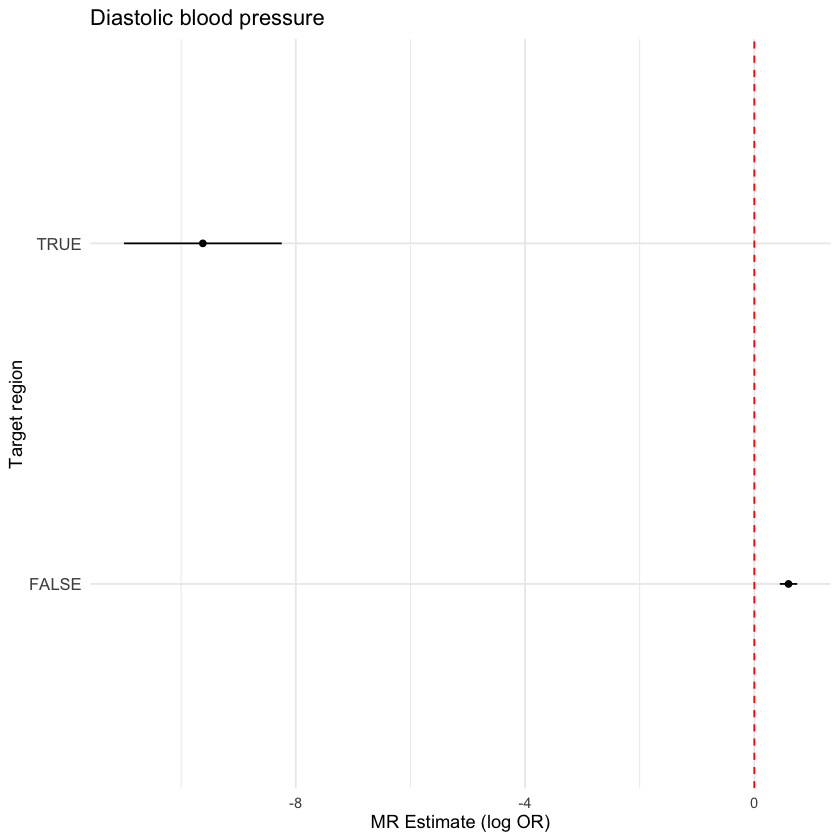

In [27]:
ggplot(mr_result %>% filter(grepl("pressure", exposure)), aes(x=b, y=grepl("target region", exposure))) +
geom_point() +
geom_errorbarh(aes(xmin=b-1.96*se, xmax=b+1.96*se), height=0) +
theme_minimal() +
geom_vline(xintercept=0, linetype="dashed", color="red") +
labs(x="MR Estimate (log OR)", y="Target region", title="Diastolic blood pressure") +
theme(axis.text.y = element_text(size=10))

Warning message in FUN(X[[i]], ...):
“Duplicated SNPs present in exposure data for phenotype 'Diastolic blood pressure, automated reading || id:ukb-b-7992. Just keeping the first instance:
rs28752924”
Extracting data for 263 SNP(s) from 1 GWAS(s)

Querying id chunk 1 of 1

Querying variant chunk 1 of 5

Querying variant chunk 2 of 5

Querying variant chunk 3 of 5

Querying variant chunk 4 of 5

Querying variant chunk 5 of 5

Finding proxies for 5 SNPs in outcome ieu-a-7

Extracting data for 5 SNP(s) from 1 GWAS(s)

Querying id chunk 1 of 1

Querying variant chunk 1 of 1

Warning message in `[.data.table`(d, !duplicated(proxy_snp.outcome), , by = outcome):
“Ignoring by/keyby because 'j' is not supplied”
Harmonising Diastolic blood pressure, automated reading || id:ukb-b-7992 (ukb-b-7992) and Coronary heart disease || id:ieu-a-7 (ieu-a-7)

Removing the following SNPs for incompatible alleles:
rs17304212

Warning message:
“Removed 1 row containing missing values or values outside the scal

[[1]]


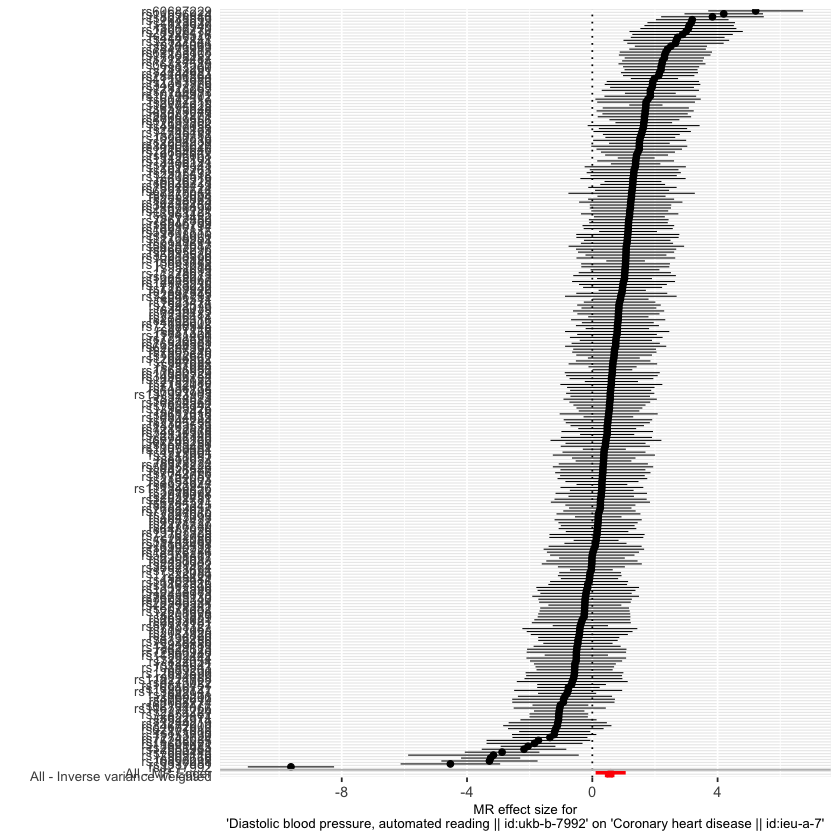

In [28]:
res <- make_dat("ukb-b-7992", "ieu-a-7")
mr_forest_plot(mr_singlesnp(res))

Summary

- This SNP associates with glaucoma, but glaucoma doesn't influence CHD so we don't think the mediating pathway is through glaucoma
- This SNP associates with DBP, and DBP does influence CHD. However, the SNP is a major outlier, and is clearly doing something else in addition to influencing blood pressure

Next steps

- Also use LD proxies for the target SNP to avoid missing potential mediating phenotypes
- Deeper dive into this SNP which appears to be an outlier for the DBP - CHD association
- Perform the same for other SNPs
- Use Cochran's Q statistic to test if the target SNP MR effect is different to the exposure instrument MR effect

In [6]:
snp <- chd$SNP[2]

phewas_result <- ieugwasr::phewas(snp, batch="ukb-b")
for(i in 1:nrow(phewas_result)) {
  message(i, ": ", phewas_result$p[i], " - ", phewas_result$trait[i])
}


1: 3.40017e-23 - Pain type(s) experienced in last month: Headache

2: 8.30042e-21 - Non-cancer illness code, self-reported: heart attack/myocardial infarction

3: 5.79963e-20 - Vascular/heart problems diagnosed by doctor: Heart attack

4: 2.39994e-19 - Diagnoses - main ICD10: I25.1 Atherosclerotic heart disease

5: 2.90001e-19 - Illnesses of father: Heart disease

6: 3.19963e-19 - Non-cancer illness code, self-reported: migraine

7: 3.40017e-17 - Operation code: coronary angioplasty (ptca) +/- stent

8: 1.29987e-14 - Operation code: coronary artery bypass grafts (cabg)

9: 3.69999e-14 - Operative procedures - main OPCS: K49.1 Percutaneous transluminal balloon angioplasty of one coronary artery

10: 1.29987e-12 - Diagnoses - secondary ICD10: I25.8 Other forms of chronic ischaemic heart disease

11: 5.60015e-12 - Systolic blood pressure, automated reading

12: 1.10002e-11 - Diagnoses - secondary ICD10: I20.9 Angina pectoris, unspecified

13: 4.00037e-11 - Non-cancer illness code, self-re

In [7]:
follow_up <- phewas_result$id[c(1, 11, 16, 35, 37)]
follow_up_instruments <- extract_instruments(outcomes = follow_up)
str(follow_up_instruments)

i <- which(chd$SNP == snp)

follow_up_instruments_target_region <- follow_up_instruments %>%
    filter(chr.exposure == chd$chr.exposure[i] & abs(pos.exposure - chd$pos.exposure[i]) < 1e6) %>%
    mutate(
        id.exposure = paste("target region - ", id.exposure),
        exposure = paste("target region - ", exposure)
    )
str(follow_up_instruments_target_region)

follow_up_instruments <- subset(follow_up_instruments, !SNP %in% follow_up_instruments_target_region$SNP) %>% 
    bind_rows(follow_up_instruments_target_region)
table(follow_up_instruments$exposure)

out <- extract_outcome_data(snps = follow_up_instruments$SNP, outcomes = "ieu-a-7")
dat <- harmonise_data(follow_up_instruments, out, action = 3)
mr_result <- mr(dat, method_list=c("mr_ivw", "mr_wald_ratio"))

'data.frame':	551 obs. of  15 variables:
 $ id.exposure           : chr  "ukb-b-11971" "ukb-b-11971" "ukb-b-11971" "ukb-b-12181" ...
 $ chr.exposure          : chr  "2" "13" "19" "12" ...
 $ pos.exposure          : int  145775399 41185309 658013 57527283 97059769 234825884 12903957 115677946 44098967 121847249 ...
 $ SNP                   : chr  "rs1006923" "rs7331212" "rs1009628" "rs11172113" ...
 $ effect_allele.exposure: chr  "C" "A" "G" "C" ...
 $ other_allele.exposure : chr  "T" "G" "A" "T" ...
 $ eaf.exposure          : num  0.321 0.262 0.845 0.412 0.322 ...
 $ beta.exposure         : num  -0.0307 -0.0263 -0.0297 -0.0138 0.0125 ...
 $ se.exposure           : num  0.00381 0.00403 0.004901 0.000844 0.00089 ...
 $ pval.exposure         : num  7.9e-16 6.4e-11 1.4e-09 1.5e-60 1.4e-44 ...
 $ samplesize.exposure   : num  151053 151053 151053 461857 461857 ...
 $ exposure              : chr  "Pulse wave Arterial Stiffness index || id:ukb-b-11971" "Pulse wave Arterial Stiffness index || i


                                         Alcohol intake frequency. || id:ukb-b-5779 
                                                                                 98 
                                         Hand grip strength (left) || id:ukb-b-7478 
                                                                                157 
                 Pain type(s) experienced in last month: Headache || id:ukb-b-12181 
                                                                                 47 
                              Pulse wave Arterial Stiffness index || id:ukb-b-11971 
                                                                                  3 
                       Systolic blood pressure, automated reading || id:ukb-b-20175 
                                                                                243 
                        target region -  Alcohol intake frequency. || id:ukb-b-5779 
                                                                

Extracting data for 544 SNP(s) from 1 GWAS(s)

Querying id chunk 1 of 1

Querying variant chunk 1 of 9

Querying variant chunk 2 of 9

Querying variant chunk 3 of 9

Querying variant chunk 4 of 9

Querying variant chunk 5 of 9

Querying variant chunk 6 of 9

Querying variant chunk 7 of 9

Querying variant chunk 8 of 9

Querying variant chunk 9 of 9

Finding proxies for 16 SNPs in outcome ieu-a-7

Extracting data for 16 SNP(s) from 1 GWAS(s)

Querying id chunk 1 of 1

Querying variant chunk 1 of 1

Warning message in `[.data.table`(d, !duplicated(proxy_snp.outcome), , by = outcome):
“Ignoring by/keyby because 'j' is not supplied”
Harmonising Pain type(s) experienced in last month: Headache || id:ukb-b-12181 (ukb-b-12181) and Coronary heart disease || id:ieu-a-7 (ieu-a-7)

Removing the following SNPs for being palindromic:
rs1535792, rs17433120, rs6539808, rs72787160, rs72938315

Removing the following SNPs for incompatible alleles:
rs34555420

Harmonising Pulse wave Arterial Stiffness i

In [8]:
mr_result

id.exposure,id.outcome,outcome,exposure,method,nsnp,b,se,pval
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ukb-b-12181,ieu-a-7,Coronary heart disease || id:ieu-a-7,Pain type(s) experienced in last month: Headache || id:ukb-b-12181,Inverse variance weighted,40,-0.8120529,0.45606689,7.498492e-02
ukb-b-11971,ieu-a-7,Coronary heart disease || id:ieu-a-7,Pulse wave Arterial Stiffness index || id:ukb-b-11971,Inverse variance weighted,3,-0.6687190,0.63510783,2.923767e-01
ukb-b-20175,ieu-a-7,Coronary heart disease || id:ieu-a-7,"Systolic blood pressure, automated reading || id:ukb-b-20175",Inverse variance weighted,219,0.6144927,0.07092825,4.571683e-18
ukb-b-7478,ieu-a-7,Coronary heart disease || id:ieu-a-7,Hand grip strength (left) || id:ukb-b-7478,Inverse variance weighted,133,-0.4015634,0.11198000,3.357529e-04
ukb-b-5779,ieu-a-7,Coronary heart disease || id:ieu-a-7,Alcohol intake frequency. || id:ukb-b-5779,Inverse variance weighted,88,0.1269387,0.05771623,2.785237e-02
target region - ukb-b-5779,ieu-a-7,Coronary heart disease || id:ieu-a-7,target region - Alcohol intake frequency. || id:ukb-b-5779,Wald ratio,1,-6.8148148,0.49896358,1.810322e-42
target region - ukb-b-20175,ieu-a-7,Coronary heart disease || id:ieu-a-7,"target region - Systolic blood pressure, automated reading || id:ukb-b-20175",Wald ratio,1,-9.0635097,0.66360736,1.810322e-42
target region - ukb-b-12181,ieu-a-7,Coronary heart disease || id:ieu-a-7,target region - Pain type(s) experienced in last month: Headache || id:ukb-b-12181,Wald ratio,1,-15.7141989,1.15055408,1.810322e-42


Warning message:
“`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead.”
`height` was translated to `width`.


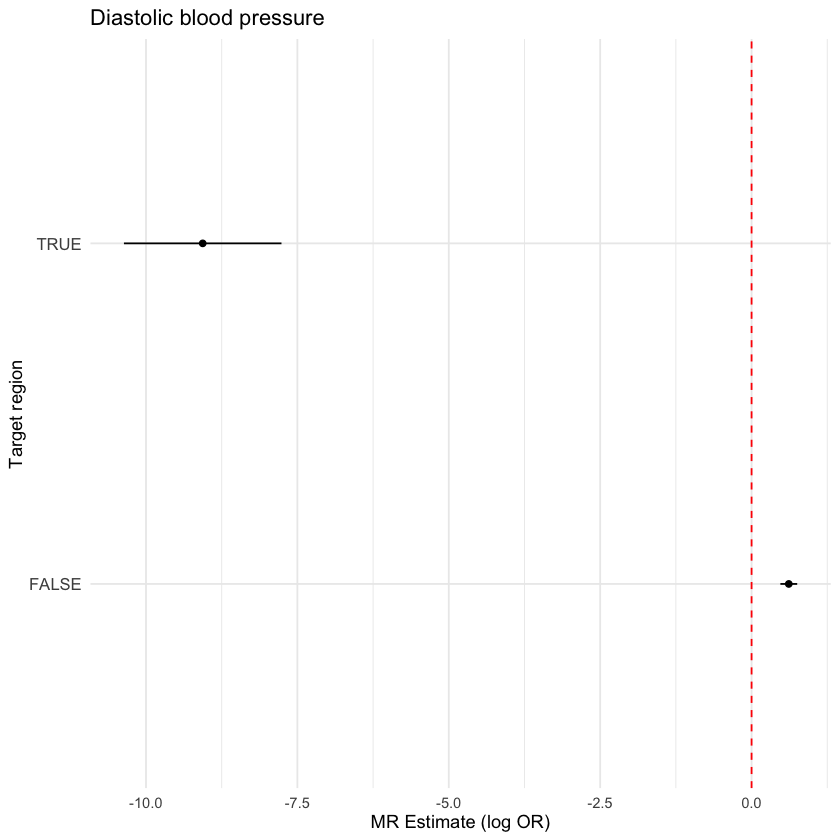

In [9]:
ggplot(mr_result %>% filter(grepl("pressure", exposure)), aes(x=b, y=grepl("target region", exposure))) +
geom_point() +
geom_errorbarh(aes(xmin=b-1.96*se, xmax=b+1.96*se), height=0) +
theme_minimal() +
geom_vline(xintercept=0, linetype="dashed", color="red") +
labs(x="MR Estimate (log OR)", y="Target region", title="Diastolic blood pressure") +
theme(axis.text.y = element_text(size=10))

`height` was translated to `width`.


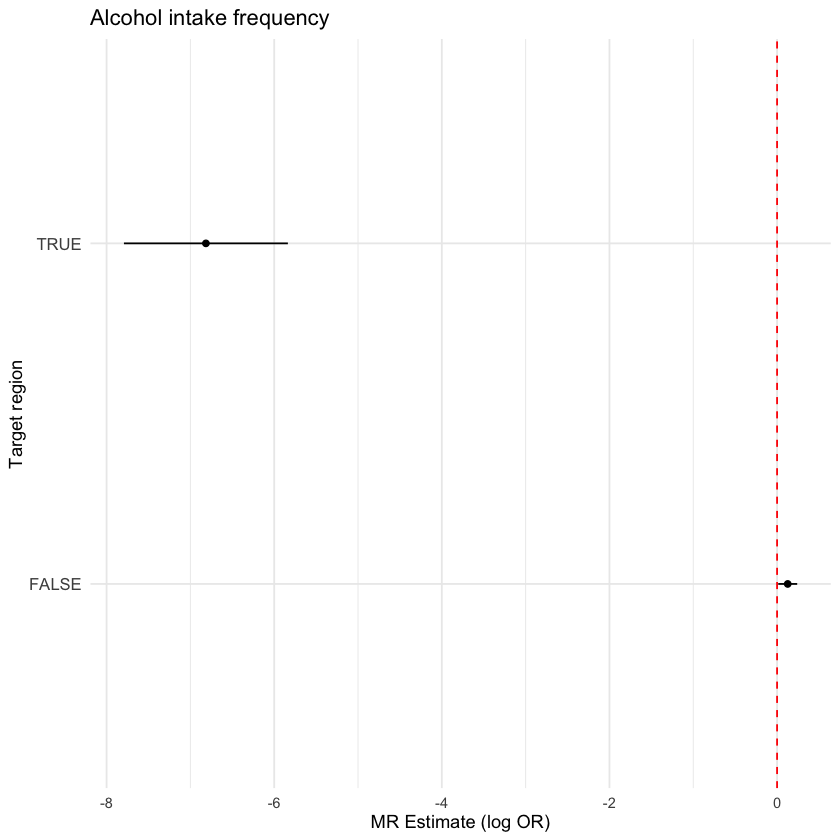

In [12]:
ggplot(mr_result %>% filter(grepl("Alcohol", exposure)), aes(x=b, y=grepl("target region", exposure))) +
geom_point() +
geom_errorbarh(aes(xmin=b-1.96*se, xmax=b+1.96*se), height=0) +
theme_minimal() +
geom_vline(xintercept=0, linetype="dashed", color="red") +
labs(x="MR Estimate (log OR)", y="Target region", title="Alcohol intake frequency") +
theme(axis.text.y = element_text(size=10))

`height` was translated to `width`.


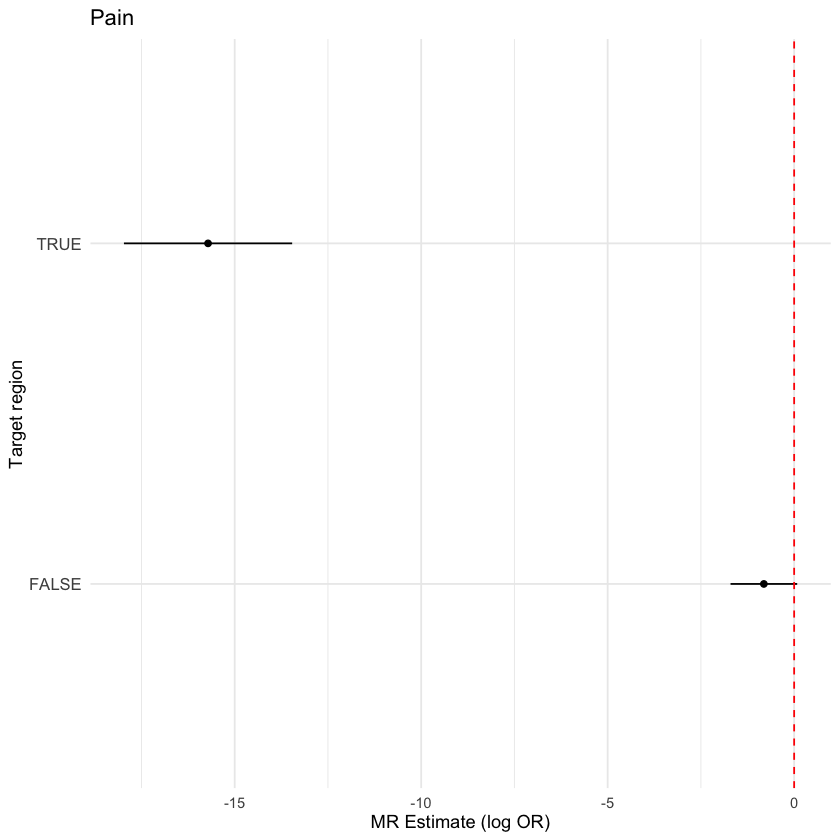

In [13]:
ggplot(mr_result %>% filter(grepl("Pain", exposure)), aes(x=b, y=grepl("target region", exposure))) +
geom_point() +
geom_errorbarh(aes(xmin=b-1.96*se, xmax=b+1.96*se), height=0) +
theme_minimal() +
geom_vline(xintercept=0, linetype="dashed", color="red") +
labs(x="MR Estimate (log OR)", y="Target region", title="Pain") +
theme(axis.text.y = element_text(size=10))

In [14]:
snp <- chd$SNP[3]

phewas_result <- ieugwasr::phewas(snp, batch="ukb-b")
for(i in 1:nrow(phewas_result)) {
  message(i, ": ", phewas_result$p[i], " - ", phewas_result$trait[i])
}


1: 2.99985e-74 - Illnesses of father: Heart disease

2: 1.29987e-56 - Diagnoses - main ICD10: I25.1 Atherosclerotic heart disease

3: 1.69981e-55 - Non-cancer illness code, self-reported: high cholesterol

4: 1.59993e-45 - Medication for cholesterol, blood pressure or diabetes: Cholesterol lowering medication

5: 1.10002e-42 - Diagnoses - secondary ICD10: E78.0 Pure hypercholesterolaemia

6: 1.10002e-40 - Non-cancer illness code, self-reported: heart attack/myocardial infarction

7: 2.09991e-40 - Vascular/heart problems diagnosed by doctor: Heart attack

8: 2.49977e-40 - Non-cancer illness code, self-reported: angina

9: 3.29989e-40 - Treatment/medication code: atorvastatin

10: 6.89922e-39 - Illnesses of mother: Heart disease

11: 3.19963e-38 - Vascular/heart problems diagnosed by doctor: Angina

12: 3.29989e-37 - Diagnoses - secondary ICD10: I25.1 Atherosclerotic heart disease

13: 4.40048e-36 - Diagnoses - secondary ICD10: I20.9 Angina pectoris, unspecified

14: 6.4003e-31 - Treatme

In [19]:
follow_up <- phewas_result$id[c(3, 5)]
follow_up_instruments <- extract_instruments(outcomes = follow_up)
str(follow_up_instruments)

i <- which(chd$SNP == snp)

follow_up_instruments_target_region <- follow_up_instruments %>%
    filter(chr.exposure == chd$chr.exposure[i] & abs(pos.exposure - chd$pos.exposure[i]) < 1e6) %>%
    mutate(
        id.exposure = paste("target region - ", id.exposure),
        exposure = paste("target region - ", exposure)
    )
str(follow_up_instruments_target_region)

follow_up_instruments <- subset(follow_up_instruments, !SNP %in% follow_up_instruments_target_region$SNP) %>% 
    bind_rows(follow_up_instruments_target_region)
table(follow_up_instruments$exposure)

out <- extract_outcome_data(snps = follow_up_instruments$SNP, outcomes = "ukb-d-I9_IHD")
dat <- harmonise_data(follow_up_instruments, out, action = 3)
mr_result <- mr(dat, method_list=c("mr_ivw", "mr_wald_ratio"))

'data.frame':	101 obs. of  15 variables:
 $ id.exposure           : chr  "ukb-b-10912" "ukb-b-10912" "ukb-b-10912" "ukb-b-10912" ...
 $ chr.exposure          : chr  "19" "19" "1" "2" ...
 $ pos.exposure          : int  45412079 11202306 109817590 21263900 116648917 126500031 55505647 160997118 74656539 44072576 ...
 $ SNP                   : chr  "rs7412" "rs6511720" "rs12740374" "rs1367117" ...
 $ effect_allele.exposure: chr  "T" "T" "T" "A" ...
 $ other_allele.exposure : chr  "C" "G" "G" "G" ...
 $ eaf.exposure          : num  0.0802 0.1188 0.2212 0.3351 0.8664 ...
 $ beta.exposure         : num  -0.0392 -0.0262 -0.0187 0.0153 -0.021 ...
 $ se.exposure           : num  0.001248 0.001047 0.000815 0.000717 0.000995 ...
 $ pval.exposure         : num  1.0e-200 7.4e-138 6.1e-117 1.3e-100 9.8e-99 ...
 $ samplesize.exposure   : num  462933 462933 462933 462933 462933 ...
 $ exposure              : chr  "Non-cancer illness code, self-reported: high cholesterol || id:ukb-b-10912" "Non-cancer


                 Diagnoses - secondary ICD10: E78.0 Pure hypercholesterolaemia || id:ukb-b-12651 
                                                                                              17 
                      Non-cancer illness code, self-reported: high cholesterol || id:ukb-b-10912 
                                                                                              77 
target region -  Diagnoses - secondary ICD10: E78.0 Pure hypercholesterolaemia || id:ukb-b-12651 
                                                                                               3 
     target region -  Non-cancer illness code, self-reported: high cholesterol || id:ukb-b-10912 
                                                                                               4 

Extracting data for 91 SNP(s) from 1 GWAS(s)

Querying id chunk 1 of 1

Querying variant chunk 1 of 2

Querying variant chunk 2 of 2

Finding proxies for 2 SNPs in outcome ukb-d-I9_IHD

Extracting data for 2 SNP(s) from 1 GWAS(s)

Querying id chunk 1 of 1

Querying variant chunk 1 of 1

Warning message in `[.data.table`(d, !duplicated(proxy_snp.outcome), , by = outcome):
“Ignoring by/keyby because 'j' is not supplied”
Harmonising Non-cancer illness code, self-reported: high cholesterol || id:ukb-b-10912 (ukb-b-10912) and Ischaemic heart disease, wide definition || id:ukb-d-I9_IHD (ukb-d-I9_IHD)

Removing the following SNPs for being palindromic:
rs10260606, rs1501908, rs1883711, rs28601761, rs34042070, rs72631343, rs7534572, rs964184

Harmonising Diagnoses - secondary ICD10: E78.0 Pure hypercholesterolaemia || id:ukb-b-12651 (ukb-b-12651) and Ischaemic heart disease, wide definition || id:ukb-d-I9_IHD (ukb-d-I9_IHD)

Removing the following SNPs for being palindromic:
rs11882796, rs1333

`height` was translated to `width`.


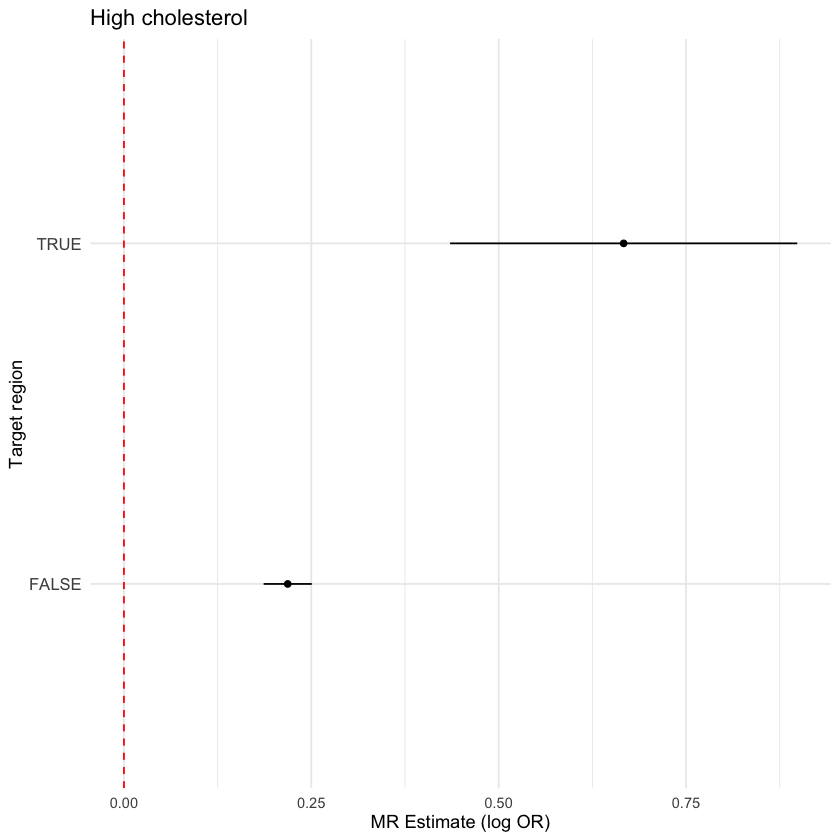

In [20]:
ggplot(mr_result %>% filter(grepl("high", exposure)), aes(x=b, y=grepl("target region", exposure))) +
geom_point() +
geom_errorbarh(aes(xmin=b-1.96*se, xmax=b+1.96*se), height=0) +
theme_minimal() +
geom_vline(xintercept=0, linetype="dashed", color="red") +
labs(x="MR Estimate (log OR)", y="Target region", title="High cholesterol") +
theme(axis.text.y = element_text(size=10))

`height` was translated to `width`.


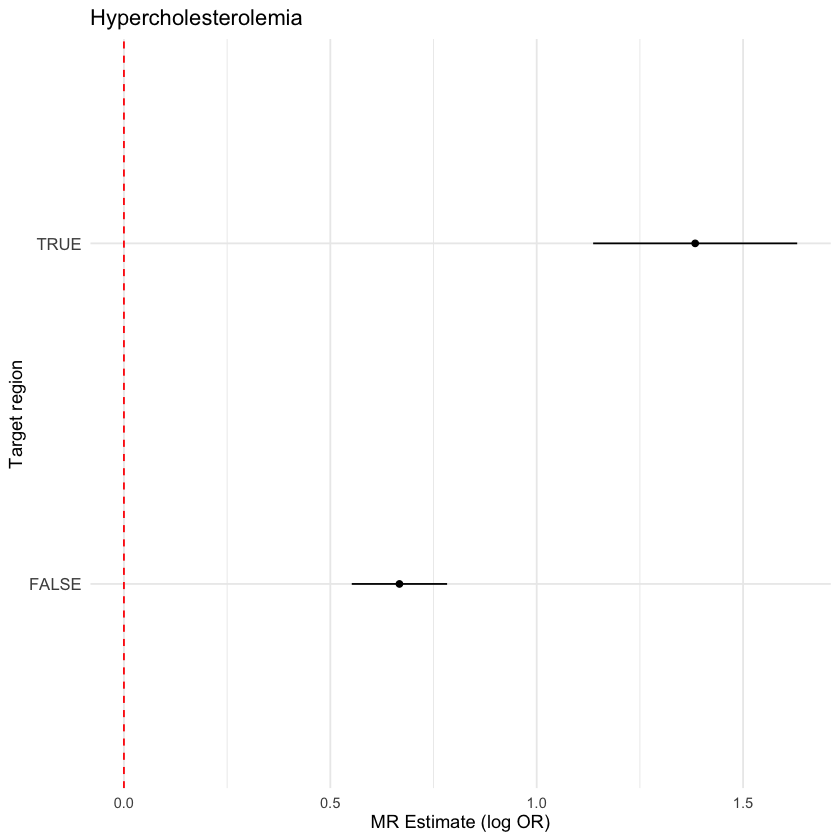

In [21]:
ggplot(mr_result %>% filter(grepl("hyper", exposure)), aes(x=b, y=grepl("target region", exposure))) +
geom_point() +
geom_errorbarh(aes(xmin=b-1.96*se, xmax=b+1.96*se), height=0) +
theme_minimal() +
geom_vline(xintercept=0, linetype="dashed", color="red") +
labs(x="MR Estimate (log OR)", y="Target region", title="Hypercholesterolemia") +
theme(axis.text.y = element_text(size=10))

In [22]:
sbpid <- "ieu-b-5138"
ldlid <- "ukb-d-30780_raw"
smokingid <- "ukb-b-10831"
alcoholid <- "ukb-b-5779"
bmiid <- "ukb-b-2303"

allintids <- c(sbpid, ldlid, smokingid, alcoholid, bmiid)

# Find which CHD SNPs associate with these traits
int_chd <- extract_outcome_data(snps = chd$SNP, outcomes = allintids) %>%
    filter(pval.outcome < 5e-8) %>%
    select(SNP, id.outcome) %>%
    distinct()
str(int_chd)

Extracting data for 41 SNP(s) from 5 GWAS(s)

Querying id chunk 1 of 1

Querying variant chunk 1 of 4

Querying variant chunk 2 of 4

Querying variant chunk 3 of 4

Querying variant chunk 4 of 4

Finding proxies for 1 SNPs in outcome ukb-d-30780_raw

Extracting data for 1 SNP(s) from 1 GWAS(s)

Querying id chunk 1 of 1

Querying variant chunk 1 of 1

Warning message in `[.data.table`(d, !duplicated(proxy_snp.outcome), , by = outcome):
“Ignoring by/keyby because 'j' is not supplied”
Finding proxies for 2 SNPs in outcome ukb-b-10831

Extracting data for 2 SNP(s) from 1 GWAS(s)

Querying id chunk 1 of 1

Querying variant chunk 1 of 1

Warning message in `[.data.table`(d, !duplicated(proxy_snp.outcome), , by = outcome):
“Ignoring by/keyby because 'j' is not supplied”
Finding proxies for 2 SNPs in outcome ukb-b-5779

Extracting data for 2 SNP(s) from 1 GWAS(s)

Querying id chunk 1 of 1

Querying variant chunk 1 of 1

Warning message in `[.data.table`(d, !duplicated(proxy_snp.outcome), , by 

'data.frame':	23 obs. of  2 variables:
 $ SNP       : chr  "rs9349379" "rs4468572" "rs9349379" "rs7528419" ...
 $ id.outcome: chr  "ieu-b-5138" "ukb-b-10831" "ukb-b-5779" "ukb-d-30780_raw" ...


In [23]:
table(int_chd$id.outcome)


     ieu-b-5138     ukb-b-10831      ukb-b-2303      ukb-b-5779 ukb-d-30780_raw 
              7               1               3               2              10 

In [24]:
# Get instrument sets for all of these traits

int_inst <- extract_instruments(outcomes = allintids)


In [25]:
# For each int trait, I need to get the CHD target SNPs that associate with it. Then for each target SNP-int pair I need to make two exposure datasets, one using the target SNP, the other using all other SNPs.

make_set <- function(int_chd, int_inst) {
    dats <- lapply(1:nrow(int_chd), function(i) {
        snp <- int_chd$SNP[i]
        int <- int_chd$id.outcome[i]
        
        int_dat <- int_inst %>% filter(id.exposure == int)
        j <- which(chd$SNP == snp)
        target_region_dat <- int_dat %>%
            filter(chr.exposure == chd$chr.exposure[j] & abs(pos.exposure - chd$pos.exposure[j]) < 1e6) %>%
            mutate(
                id.exposure = paste0("target - ", snp, id.exposure),
                exposure = paste0("target - ", snp, " - ", exposure)
            )
        
        other_region_dat <- subset(int_dat, !SNP %in% target_region_dat$SNP)
        
        bind_rows(other_region_dat, target_region_dat)
    })
    names(dats) <- paste(int_chd$SNP, int_chd$id.outcome, sep="_")
    dats
}

exp_sets <- make_set(int_chd, int_inst)


In [26]:
str(exp_sets)

List of 23
 $ rs9349379_ieu-b-5138       :'data.frame':	285 obs. of  15 variables:
  ..$ id.exposure           : chr [1:285] "ieu-b-5138" "ieu-b-5138" "ieu-b-5138" "ieu-b-5138" ...
  ..$ chr.exposure          : chr [1:285] "5" "7" "4" "1" ...
  ..$ pos.exposure          : int [1:285] 32831939 106412082 81174592 11895795 90046518 100610546 18727959 104906211 11526765 164954174 ...
  ..$ SNP                   : chr [1:285] "rs12656497" "rs62481856" "rs13125101" "rs55857306" ...
  ..$ effect_allele.exposure: chr [1:285] "C" "A" "A" "A" ...
  ..$ other_allele.exposure : chr [1:285] "T" "G" "G" "G" ...
  ..$ eaf.exposure          : num [1:285] 0.596 0.197 0.292 0.162 0.829 ...
  ..$ beta.exposure         : num [1:285] 0.621 0.75 0.656 -0.752 0.683 ...
  ..$ se.exposure           : num [1:285] 0.037 0.0456 0.04 0.0492 0.0483 ...
  ..$ pval.exposure         : num [1:285] 4.4e-63 7.0e-61 2.0e-60 1.2e-52 2.0e-45 ...
  ..$ samplesize.exposure   : num [1:285] NA NA NA NA NA NA NA NA NA NA ...
  .

In [27]:
table(exp_sets[[3]]$exposure)


                     Alcohol intake frequency. || id:ukb-b-5779 
                                                             98 
target - rs9349379 - Alcohol intake frequency. || id:ukb-b-5779 
                                                              1 

In [ ]:
outid <- "ukb-d-I9_IHD"
outdat <- extract_outcome_data(snps = int_inst$SNP, outcomes = outid)
str(outdat)
phewas_result <- phewas(chd$SNP)
save(outdat, exp_sets, int_chd, int_inst, int_chd, chd, phewas_result, file = "chd_phewas_results.Rdata")

'data.frame':	7756 obs. of  23 variables:
 $ SNP                  : chr  "rs9435731" "rs17357954" "rs17038164" "rs11205303" ...
 $ chr                  : chr  "1" "1" "1" "1" ...
 $ pos                  : chr  "17306029" "41487337" "118862669" "149906413" ...
 $ beta.outcome         : num  -0.0182 0.0228 -0.003 0.0077 0.0102 ...
 $ se.outcome           : num  0.0079 0.0101 0.0087 0.0084 0.0092 0.0081 0.0086 0.0325 0.0188 0.0103 ...
 $ samplesize.outcome   : num  161405 161405 161405 161405 161405 ...
 $ pval.outcome         : num  0.022 0.0242 0.732 0.3584 0.2696 ...
 $ eaf.outcome          : num  0.472 0.186 0.271 0.384 0.223 0.369 0.364 0.02 0.064 0.199 ...
 $ effect_allele.outcome: chr  "A" "T" "C" "C" ...
 $ other_allele.outcome : chr  "C" "G" "T" "T" ...
 $ outcome              : chr  "Schizophrenia || id:ieu-b-5100" "Schizophrenia || id:ieu-b-5100" "Schizophrenia || id:ieu-b-5100" "Schizophrenia || id:ieu-b-5100" ...
 $ id.outcome           : chr  "ieu-b-5100" "ieu-b-5100" "ieu-b

In [30]:
load("chd_phewas_results.Rdata")

cochran_q <- function(b, se) {
    w <- 1 / se^2
    q <- sum(w * (b - sum(w * b) / sum(w))^2)
    qpval <- pchisq(q, df=length(b)-1, lower.tail=FALSE)
    list(q=q, p=qpval)
}

res_sets <- lapply(exp_sets, function(exp_set) {
    dat <- harmonise_data(exp_set, outdat, action = 3)
    o <- mr(dat, method_list=c("mr_ivw", "mr_wald_ratio"))
    if(nrow(o) != 2) return(NULL)
    expname <- o$exposure[!grepl("target", o$exposure)]
    expname <- strsplit(expname, "\\|")[[1]][1]
    o$int_trait <- expname
    rsid <- o$exposure[grepl("target", o$exposure)] %>% {strsplit(., " - ")[[1]][2]}
    o$rsid <- rsid
    o$exposure[grepl(rsid, o$exposure)] <- rsid
    ind <- !grepl(rsid, o$exposure)
    o$exposure[ind] <- "All other SNPs"
    qres <- cochran_q(o$b, o$se)
    o$cochran_q <- qres$q
    o$cochran_p <- qres$p
    o$cochran_q[ind] <- 1
    o$cochran_p[ind] <- 1
    
    o
})

Harmonising Systolic Blood Pressure (SBP) || id:ieu-b-5138 (ieu-b-5138) and Schizophrenia || id:ieu-b-5100 (ieu-b-5100)

Removing the following SNPs for being palindromic:
rs10260816, rs12258967, rs17010961

Harmonising target - rs9349379 - Systolic Blood Pressure (SBP) || id:ieu-b-5138 (target - rs9349379ieu-b-5138) and Schizophrenia || id:ieu-b-5100 (ieu-b-5100)

Analysing 'ieu-b-5138' on 'ieu-b-5100'

Analysing 'target - rs9349379ieu-b-5138' on 'ieu-b-5100'

Harmonising Pack years of smoking || id:ukb-b-10831 (ukb-b-10831) and Schizophrenia || id:ieu-b-5100 (ieu-b-5100)

Removing the following SNPs for being palindromic:
rs7581162, rs9358909

Harmonising target - rs4468572 - Pack years of smoking || id:ukb-b-10831 (target - rs4468572ukb-b-10831) and Schizophrenia || id:ieu-b-5100 (ieu-b-5100)

Analysing 'ukb-b-10831' on 'ieu-b-5100'

Analysing 'target - rs4468572ukb-b-10831' on 'ieu-b-5100'

Harmonising Alcohol intake frequency. || id:ukb-b-5779 (ukb-b-5779) and Schizophrenia || id:

In [31]:
res_sets[[1]]

id.exposure,id.outcome,outcome,exposure,method,nsnp,b,se,pval,int_trait,rsid,cochran_q,cochran_p
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
ieu-b-5138,ieu-b-5100,Schizophrenia || id:ieu-b-5100,All other SNPs,Inverse variance weighted,39,0.0117976505,0.01063296,0.2671989,Systolic Blood Pressure (SBP),rs9349379,1.0000000,1.0000000
target - rs9349379ieu-b-5138,ieu-b-5100,Schizophrenia || id:ieu-b-5100,rs9349379,Wald ratio,1,-0.0007600555,0.03077917,0.9802992,Systolic Blood Pressure (SBP),rs9349379,0.1487113,0.6997699


`height` was translated to `width`.


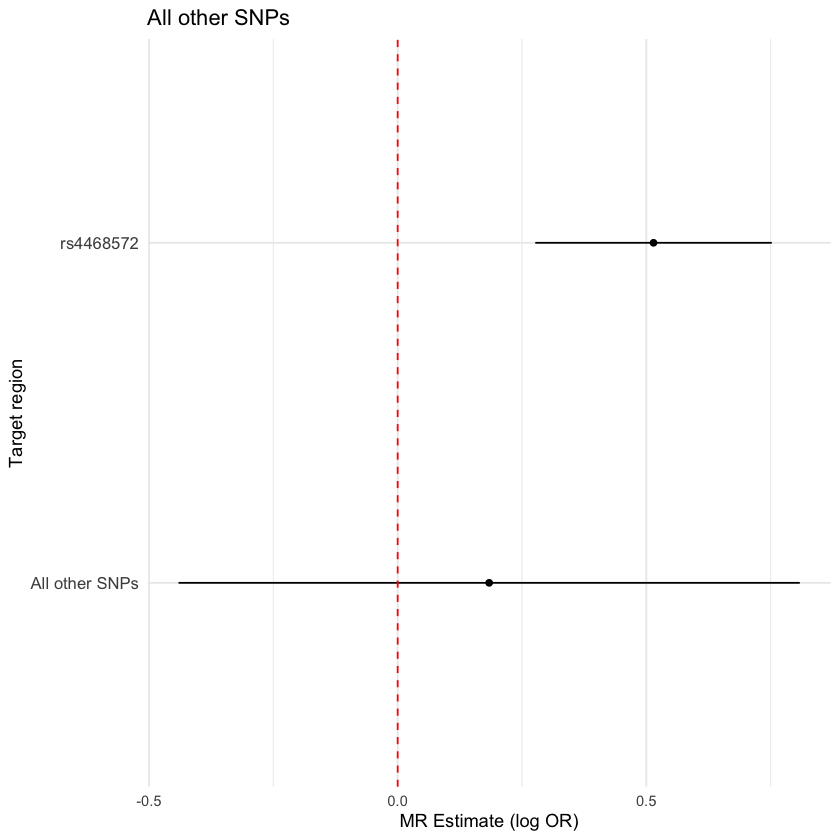

In [34]:
plot_one <- function(mr_result, title) {
    ggplot(mr_result, aes(x=b, y=exposure)) +
    geom_point() +
    geom_errorbarh(aes(xmin=b-1.96*se, xmax=b+1.96*se), height=0) +
    theme_minimal() +
    geom_vline(xintercept=0, linetype="dashed", color="red") +
    labs(x="MR Estimate (log OR)", y="Target region", title=title) +
    theme(axis.text.y = element_text(size=10))
}

plot_one(res_sets[[2]], res_sets[[1]]$exposure[1])


`height` was translated to `width`.


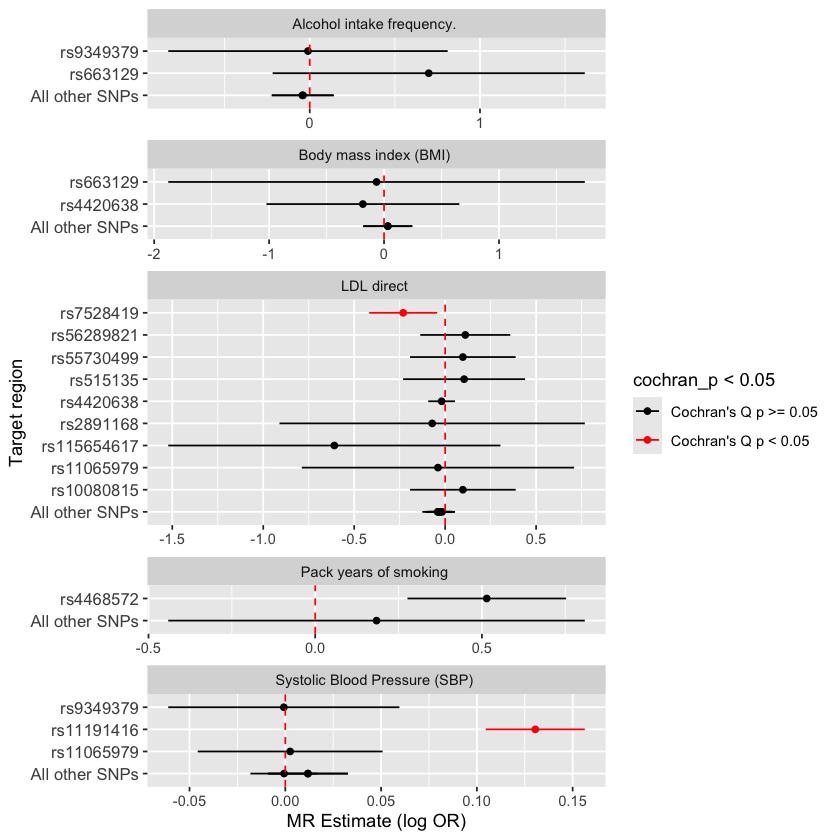

In [35]:
plot_int <- function(res_sets, int_id) {
    # keep mr_results that grepl int_name in the exposure name
    rs <- bind_rows(res_sets)
    ggplot(rs, aes(x=b, y=exposure)) +
    geom_point(aes(colour = cochran_p < 0.05)) +
    geom_errorbarh(aes(xmin=b-1.96*se, xmax=b+1.96*se, colour = cochran_p < 0.05), height=0) +
    geom_vline(xintercept=0, linetype="dashed", color="red") +
    labs(x="MR Estimate (log OR)", y="Target region") +
    facet_wrap(int_trait ~ ., scales = "free", ncol=1, space="free_y") +
    scale_colour_manual(values=c("black", "red"), labels=c("Cochran's Q p >= 0.05", "Cochran's Q p < 0.05")) +
    theme(axis.text.y = element_text(size=10))
}

plot_int(res_sets, sbpid)

In [129]:
temp <- int_inst %>% filter(id.exposure == sbpid) %>% mutate(type = "background")
temp2 <- subset(chd, SNP %in% int_chd$SNP[int_chd$id.outcome == sbpid])
for(i in 1:nrow(temp2)) {
    j <- which(temp$chr.exposure == temp2$chr.exposure[i] & abs(temp$pos.exposure - temp2$pos.exposure[i]) < 1e6)
    temp$type[j] <- "chd hit"
}
table(temp$type)
table(temp$exposure)


background    chd hit 
       277          8 


Systolic Blood Pressure (SBP) || id:ieu-b-5138 
                                           285 

In [ ]:
generate_q_dist <- function(temp, outdat) {
    lapply(1:nrow(temp), function(i) {
        temp2 <- temp
        temp2$id.exposure[i] <- "target"
        dat <- harmonise_data(temp2, outdat, action = 3)
        o <- mr(dat, method_list=c("mr_ivw", "mr_wald_ratio"))
        if(nrow(o) != 2) return(NULL)
        tibble(
            q = cochran_q(o$b, o$se)$q,
            type = temp$type[i],
            snp = temp$SNP[i]
        )
    }) %>% bind_rows()
}

qdist_res <- lapply(allintids, function(int_id) {
    temp <- int_inst %>% filter(id.exposure == int_id) %>% mutate(type = "background")
    temp2 <- subset(chd, SNP %in% int_chd$SNP[int_chd$id.outcome == int_id])
    for(i in 1:nrow(temp2)) {
        j <- which(temp$chr.exposure == temp2$chr.exposure[i] & abs(temp$pos.exposure - temp2$pos.exposure[i]) < 1e6)
        temp$type[j] <- "chd hit"
    }
    generate_q_dist(temp, outdat) %>% mutate(int_id = int_id)
}) %>% bind_rows()
    

Harmonising Systolic Blood Pressure (SBP) || id:ieu-b-5138 (ieu-b-5138) and Ischaemic heart disease, wide definition || id:ukb-d-I9_IHD (ukb-d-I9_IHD)

Removing the following SNPs for being palindromic:
rs10029530, rs10260816, rs11207423, rs1126930, rs12258967, rs12321, rs1250259, rs12888271, rs12919876, rs1332796, rs143158497, rs17010961, rs17080102, rs1860302, rs2075636, rs2288276, rs2382818, rs2529090, rs268263, rs28439224, rs3786516, rs3845811, rs3863248, rs396369, rs4396807, rs4909595, rs536338, rs62162674, rs71313932, rs7136054, rs73036519, rs7714219, rs77243533

Removing the following SNPs for incompatible alleles:
rs17811915, rs34057719

Harmonising Systolic Blood Pressure (SBP) || id:ieu-b-5138 (target) and Ischaemic heart disease, wide definition || id:ukb-d-I9_IHD (ukb-d-I9_IHD)

Analysing 'ieu-b-5138' on 'ukb-d-I9_IHD'

Analysing 'target' on 'ukb-d-I9_IHD'

Harmonising Systolic Blood Pressure (SBP) || id:ieu-b-5138 (ieu-b-5138) and Ischaemic heart disease, wide definition |

In [153]:
gi <- gwasinfo(allintids)
qdist_res <- inner_join(qdist_res, gi %>% select(id, trait), by=c("int_id"="id"))


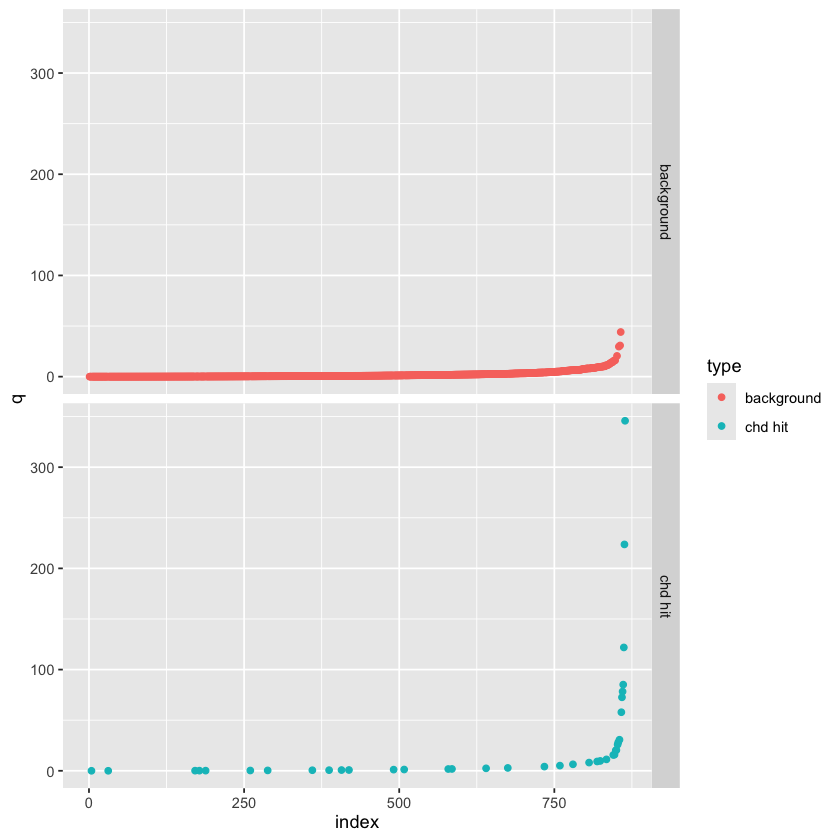

In [154]:
qdist_res %>%
    arrange(q) %>%
    mutate(index=1:n()) %>%
    ggplot(., aes(x=index, y=q, colour=type)) +
    geom_point() +
    facet_grid(type ~ .)

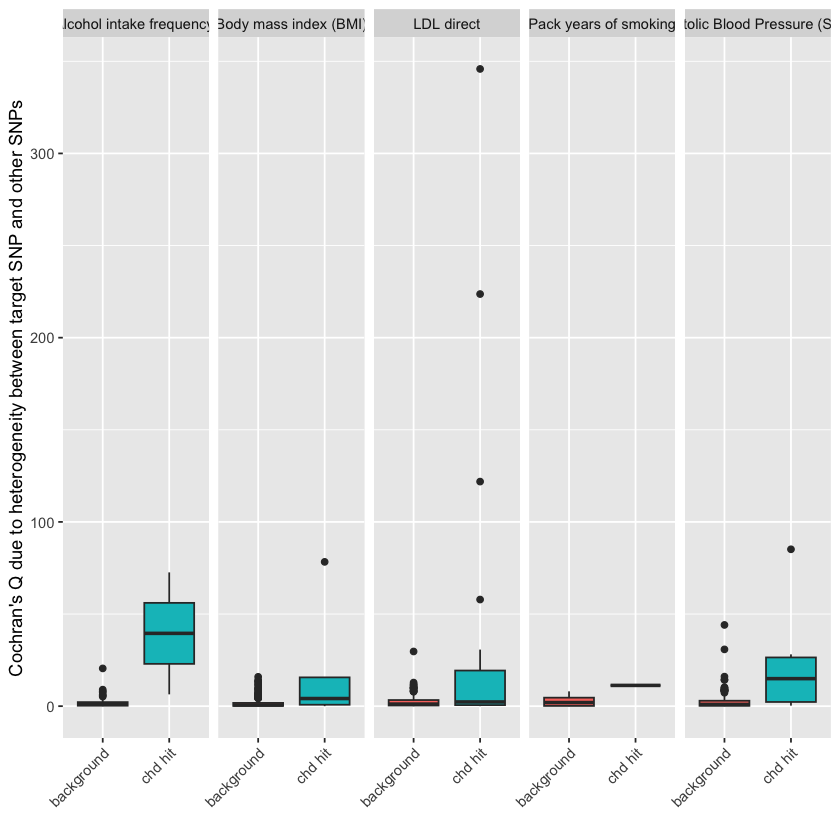

In [155]:
    
    ggplot(qdist_res, aes(x=type, y=q, fill=type)) +
    geom_boxplot() +
    facet_grid(. ~ trait) +
    theme(legend.position="none", axis.text.x = element_text(angle=45, hjust=1)) +
    labs(x="", y="Cochran's Q due to heterogeneity between target SNP and other SNPs")

In [2]:
res_sets <- lapply(exp_sets, function(exp_set) {
    dat <- harmonise_data(exp_set, outdat, action = 3)
    o <- mr(dat, method_list=c("mr_ivw", "mr_wald_ratio"))
    if(nrow(o) != 2) return(NULL)
    expname <- o$exposure[!grepl("target", o$exposure)]
    expname <- strsplit(expname, "\\|")[[1]][1]
    o$int_trait <- expname
    rsid <- o$exposure[grepl("target", o$exposure)] %>% {strsplit(., " - ")[[1]][2]}
    o$rsid <- rsid
    o$exposure[grepl(rsid, o$exposure)] <- rsid
    ind <- !grepl(rsid, o$exposure)
    o$exposure[ind] <- "All other SNPs"
    qres <- cochran_q(o$b, o$se)
    o$cochran_q <- qres$q
    o$cochran_p <- qres$p
    o$cochran_q[ind] <- 1
    o$cochran_p[ind] <- 1

    p <- mr_single_snp(dat)
    
    
    o
})

ERROR: Error: object 'exp_sets' not found


In [4]:
load("phewas_result.Rdata")
ls()

[1] "allintids"              "int_inst"               "outdat"                
[4] "phewas_result_filtered" "scz"

In [ ]:
str